In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#Replacing blanks with 0 as tenure is 0 and no total charges are recorded

In [20]:
df["TotalCharges"]=df["TotalCharges"].replace(" ", "0")
df["TotalCharges"]=df["TotalCharges"].astype("float")

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [22]:
df.isnull().sum().sum()

0

In [23]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [24]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [25]:
df.duplicated().sum()

0

In [26]:
df["customerID"].duplicated().sum()

0

In [27]:
def conv(value):
    if value==1:
        return "Yes"
    else:
        return "No"
df['SeniorCitizen']=df['SeniorCitizen'].apply(conv)        

In [ ]:
#Converted 0 and 1 value of senior citizen to Yes/No to make it easier to understand

In [28]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df.head(40)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ToatlCharges
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,1889.5
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,108.15
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1840.75
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,151.65
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,820.5
6,1452-KIOVK,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,1949.4
7,6713-OKOMC,Female,No,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No,301.9
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,3046.05
9,6388-TABGU,Male,No,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No,3487.95


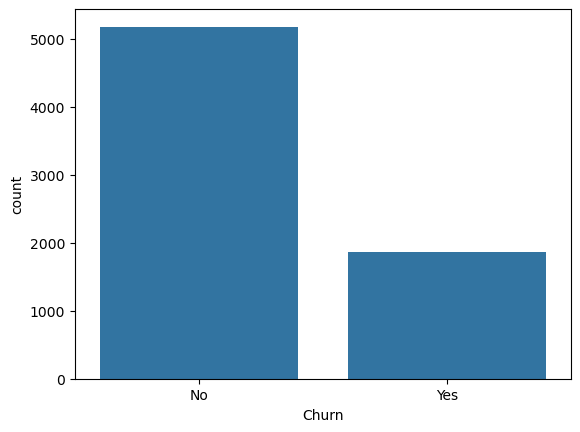

In [31]:
sns.countplot(x ='Churn',data=df)
plt.show()

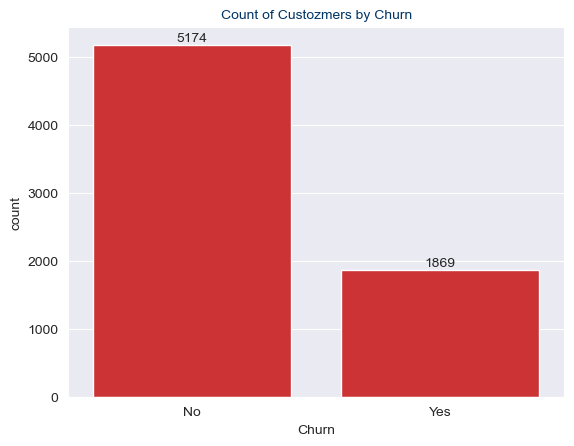

In [43]:
sns.set_style("darkgrid")   # or whitegrid, white, ticks
sns.set_palette("Set1")

ax = sns.countplot(x ='Churn',data=df,)

ax.bar_label(ax.containers[0])
plt.title("Count of Custozmers by Churn",fontsize=10, color='#003566')
plt.show()

ValueError: could not convert string to float: 'No'

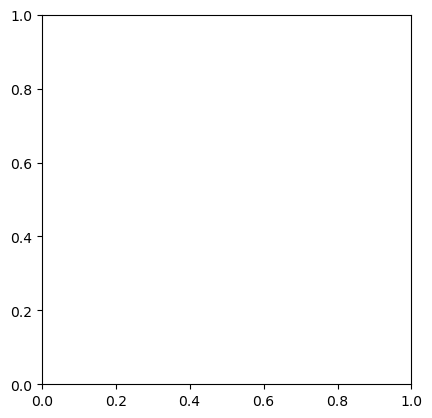

In [6]:
plt.pie(df['Churn'])
plt.show
#ValueError: could not convert string to float: 'No'

#ValueError: could not convert string to float: 'No' that's why we are making data into group by.

In [8]:
gb=df.groupby("Churn").agg({'Churn':"count"})
gb

,Churn
Churn,
No,5174
Yes,1869


<function matplotlib.pyplot.show(close=None, block=None)>

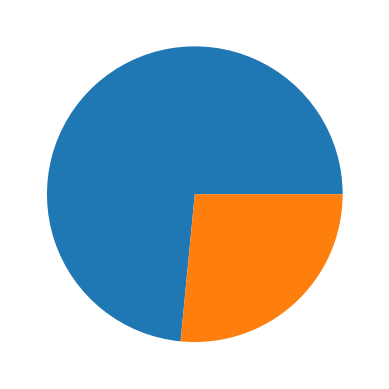

In [10]:
gb=df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'])
plt.show

#We have partitions here but who to decide which partition is for whome that's why we are using labels here

<function matplotlib.pyplot.show(close=None, block=None)>

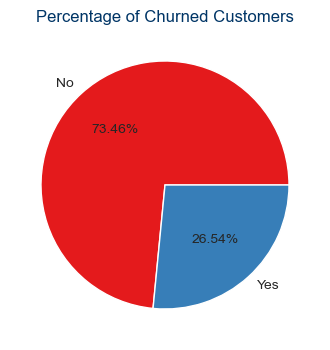

In [40]:
sns.set_style("darkgrid")   # or whitegrid, white, ticks
sns.set_palette("Set1")

plt.figure(figsize=(4,5))
gb=df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'],labels=gb.index, autopct="%1.2f%%",)
plt.title("Percentage of Churned Customers", fontsize=12, color='#003566')
plt.show

#From the given pie chart we can conclude that 26.54% of our customers have churned out.

#Now let's Explore the reason behind it.

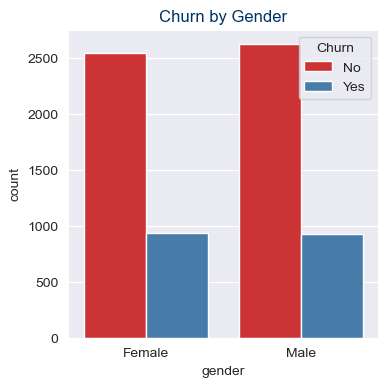

In [6]:
sns.set_style("darkgrid")   # or whitegrid, white, ticks
sns.set_palette("Set1")

plt.figure(figsize=(4,4))
sns.countplot(x="gender",data=df, hue="Churn")
plt.title("Churn by Gender", fontsize=12, color='#003566')
plt.show()


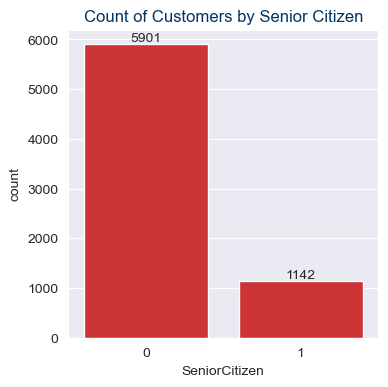

In [7]:
sns.set_style("darkgrid")   # or whitegrid, white, ticks
sns.set_palette("Set1")

plt.figure(figsize=(4,4))
ax=sns.countplot(x="SeniorCitizen",data=df,)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Senior Citizen",fontsize=12, color='#003566')
plt.show()

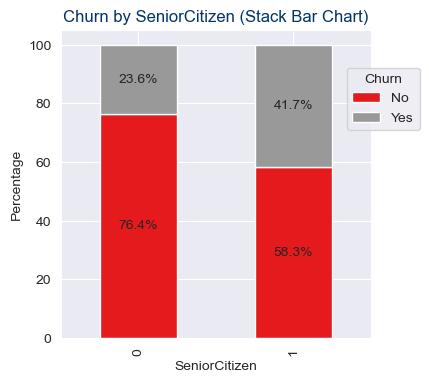

In [5]:
# Create cross-tab
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# Convert to percentage
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot stacked bar
ax = ct_percent.plot(kind='bar', stacked=True, figsize=(4,4), colormap='Set1')

# Add percentage labels
for i in range(len(ct_percent)):
    cumulative = 0
    for j in range(len(ct_percent.columns)):
        value = ct_percent.iloc[i, j]
        ax.text(i, cumulative + value/2, f"{value:.1f}%", ha='center', va='center')
        cumulative += value

plt.title("Churn by SeniorCitizen (Stack Bar Chart)", fontsize=12, color='#003566')
plt.ylabel("Percentage")
plt.legend(title="Churn",bbox_to_anchor=(0.9,0.9)) #Customers Legend location
plt.show()

#Comparatively a greater percentage of people in senior citizen category have churned

<function matplotlib.pyplot.show(close=None, block=None)>

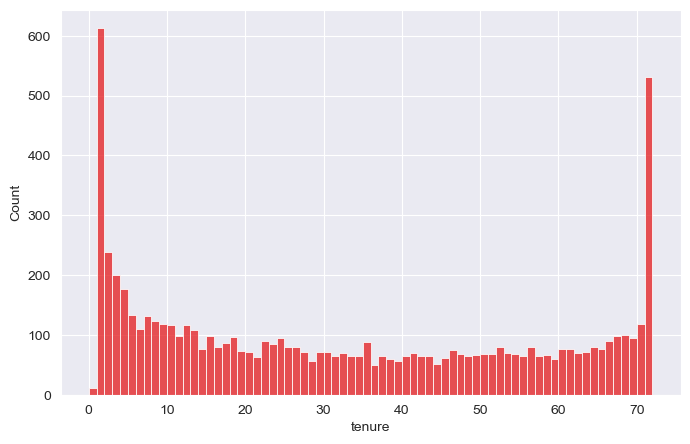

In [59]:
plt.figure(figsize=(8,5))
sns.histplot(x="tenure",data=df, bins=72)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

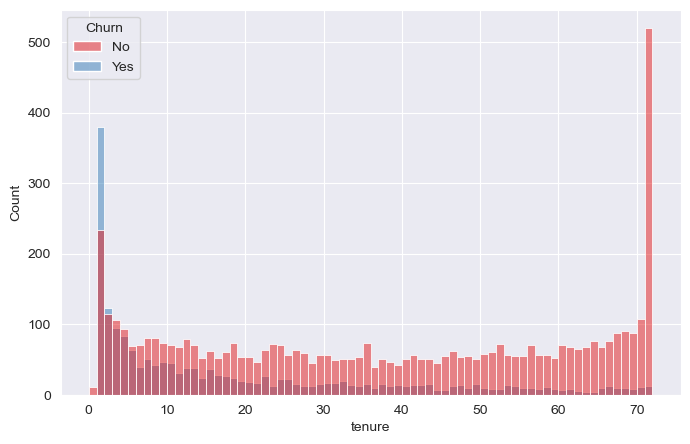

In [60]:
plt.figure(figsize=(8,5))
sns.histplot(x="tenure",data=df, bins=72,hue="Churn")
plt.show

#People who have used our services for long time have stayed and People who have used our services for #1 or #2 months have churned.

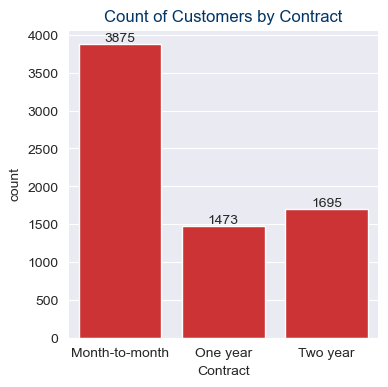

In [8]:
sns.set_style("darkgrid")   # or whitegrid, white, ticks
sns.set_palette("Set1")

plt.figure(figsize=(4,4))
ax=sns.countplot(x="Contract",data=df,)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract",fontsize=12, color='#003566')
plt.show()

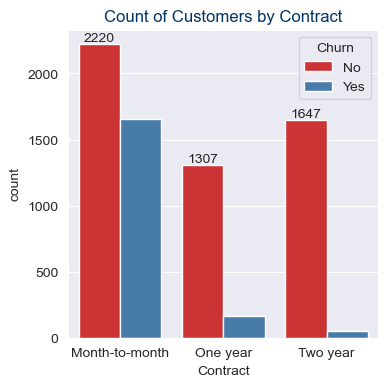

In [9]:
sns.set_style("darkgrid")   # or whitegrid, white, ticks
sns.set_palette("Set1")

plt.figure(figsize=(4,4))
ax=sns.countplot(x="Contract",data=df, hue='Churn')
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract",fontsize=12, color='#003566')
plt.show()

#People who have month to month contract are likely to churn then from those who have 1 or 2 years of contract.

In [10]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

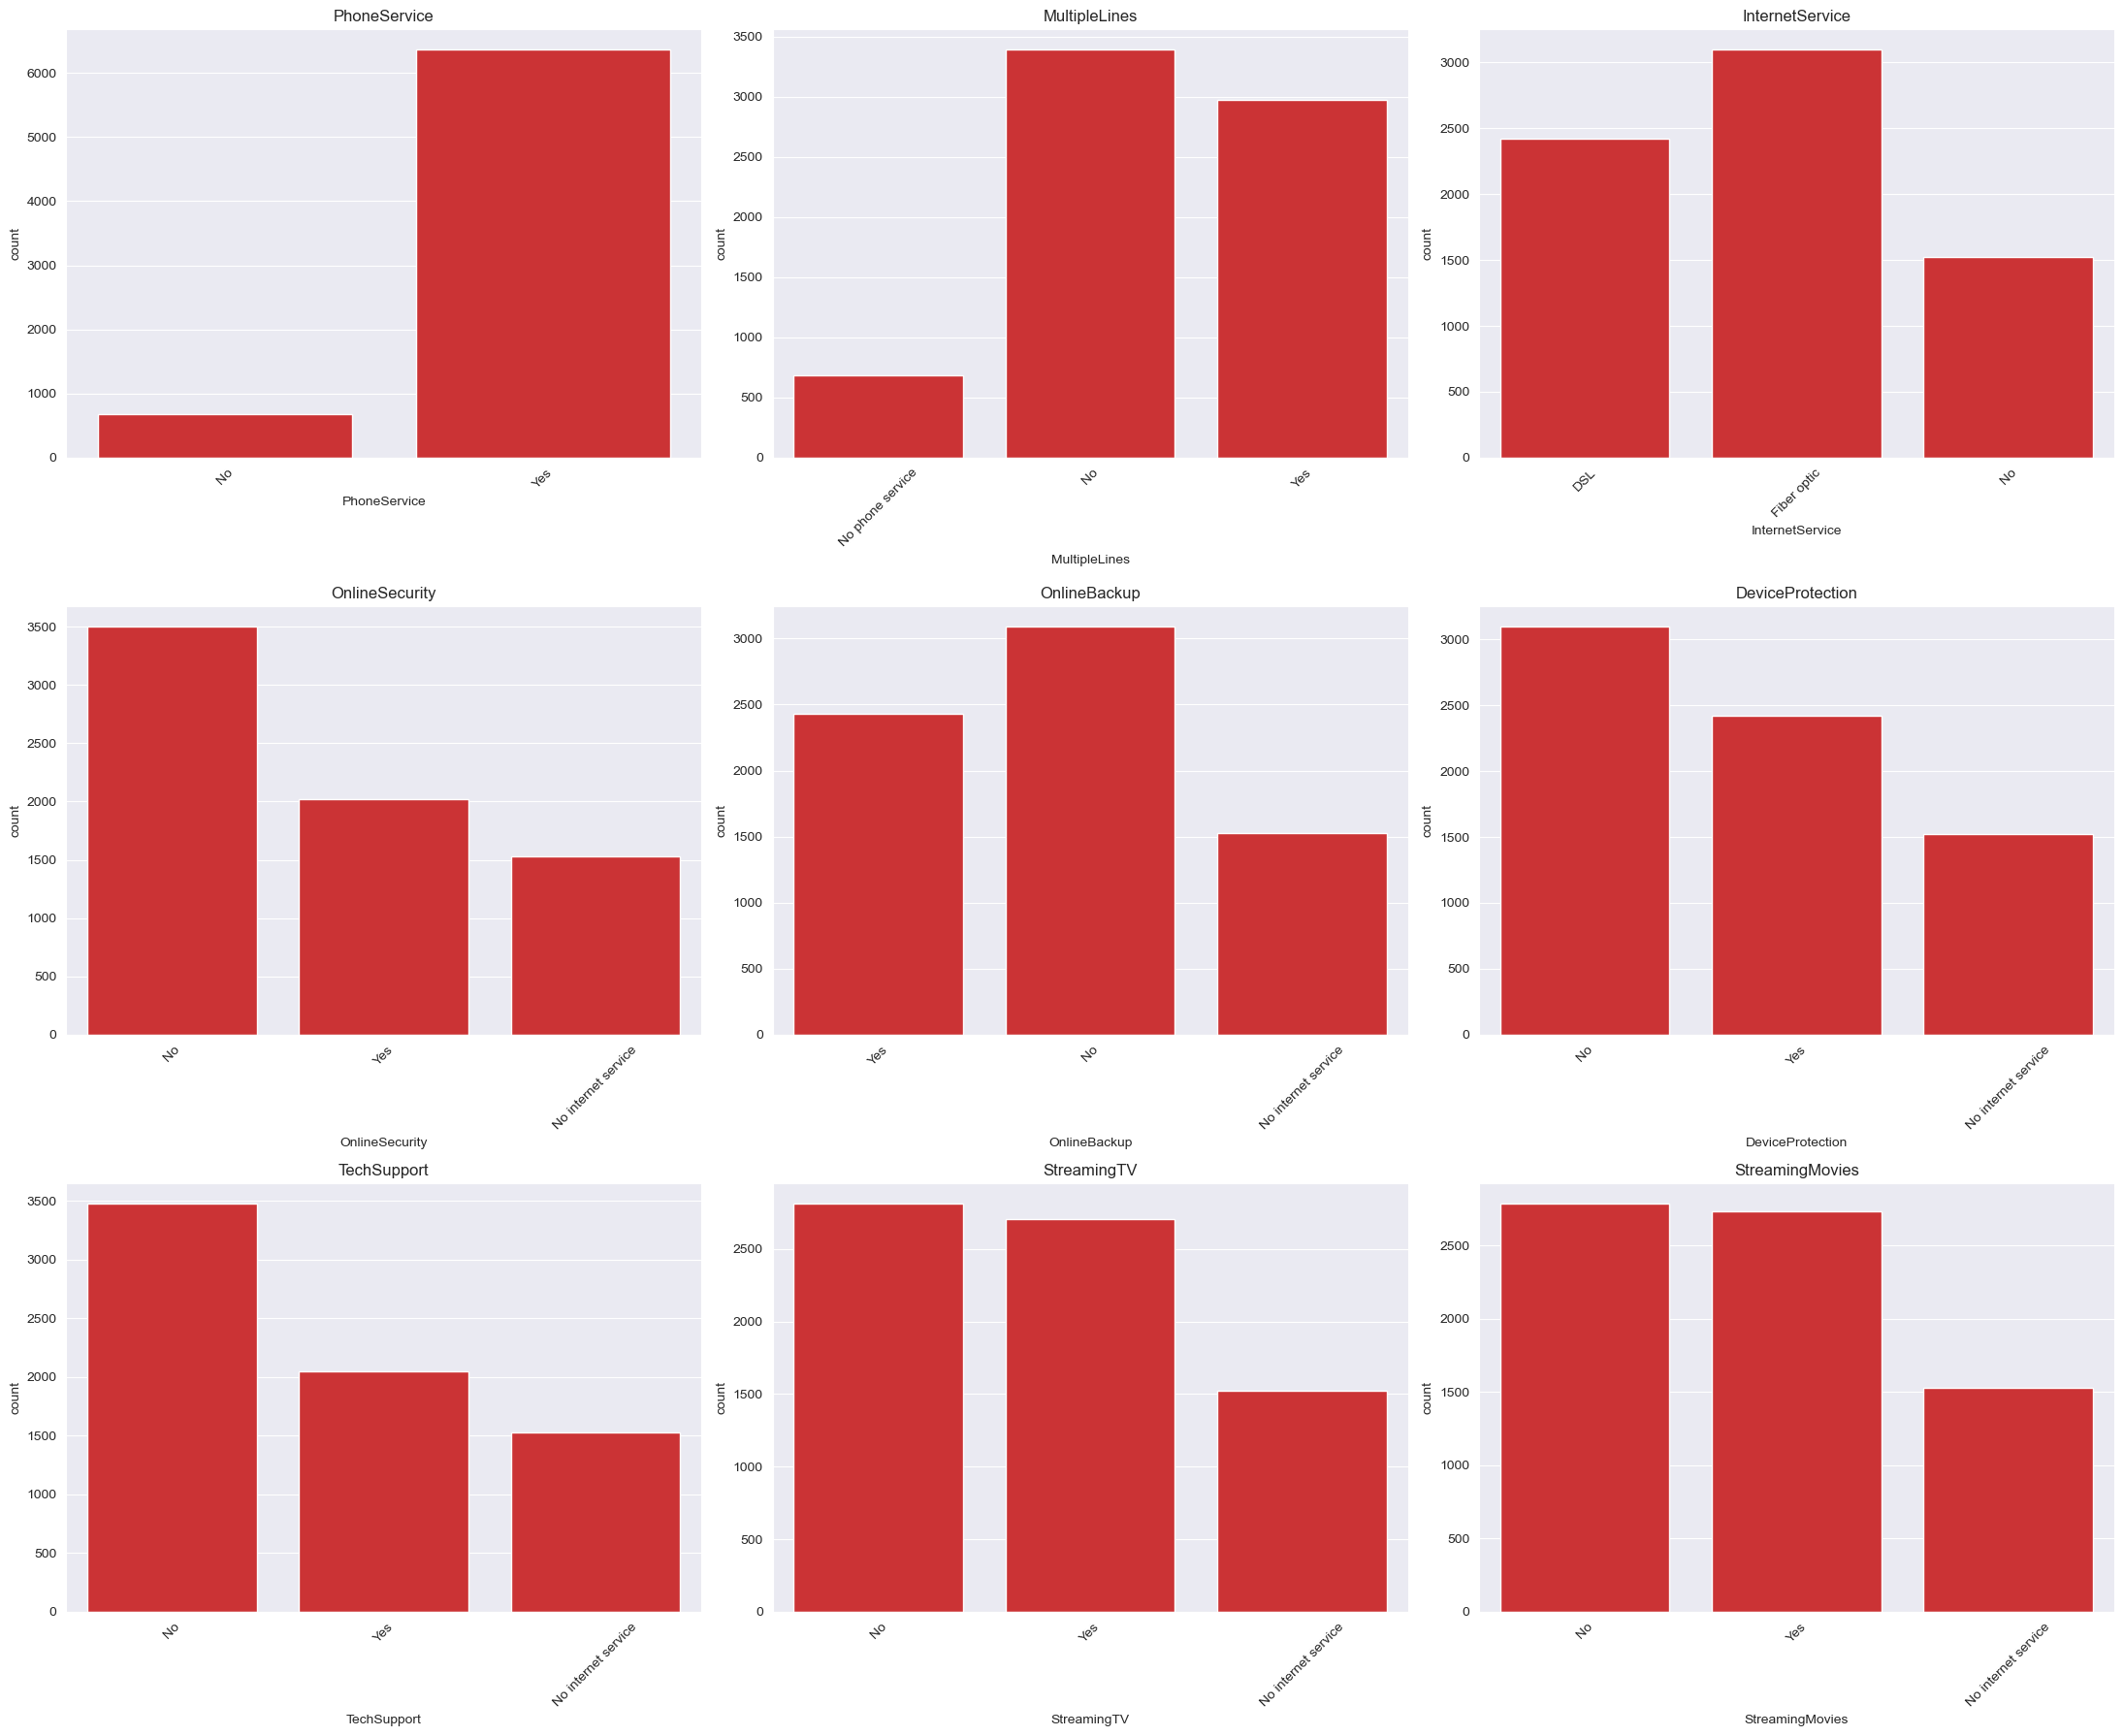

In [16]:
import math  # used to calculate number of rows dynamically

# List of categorical columns you want to plot
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Decide number of columns in subplot grid
n_cols = 3  

# Calculate required rows (so all plots fit properly)
n_rows = math.ceil(len(cols) / n_cols)

# Set overall figure size (height depends on number of rows)
plt.figure(figsize=(22, 6 * n_rows))

# Loop through each column and create a subplot
for i, col in enumerate(cols, 1):
    
    # Create subplot at position i
    plt.subplot(n_rows, n_cols, i)
    
    # Create countplot for the column
    sns.countplot(data=df, x=col)
    
    # Set title as column name
    plt.title(col)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display all plots
plt.show()

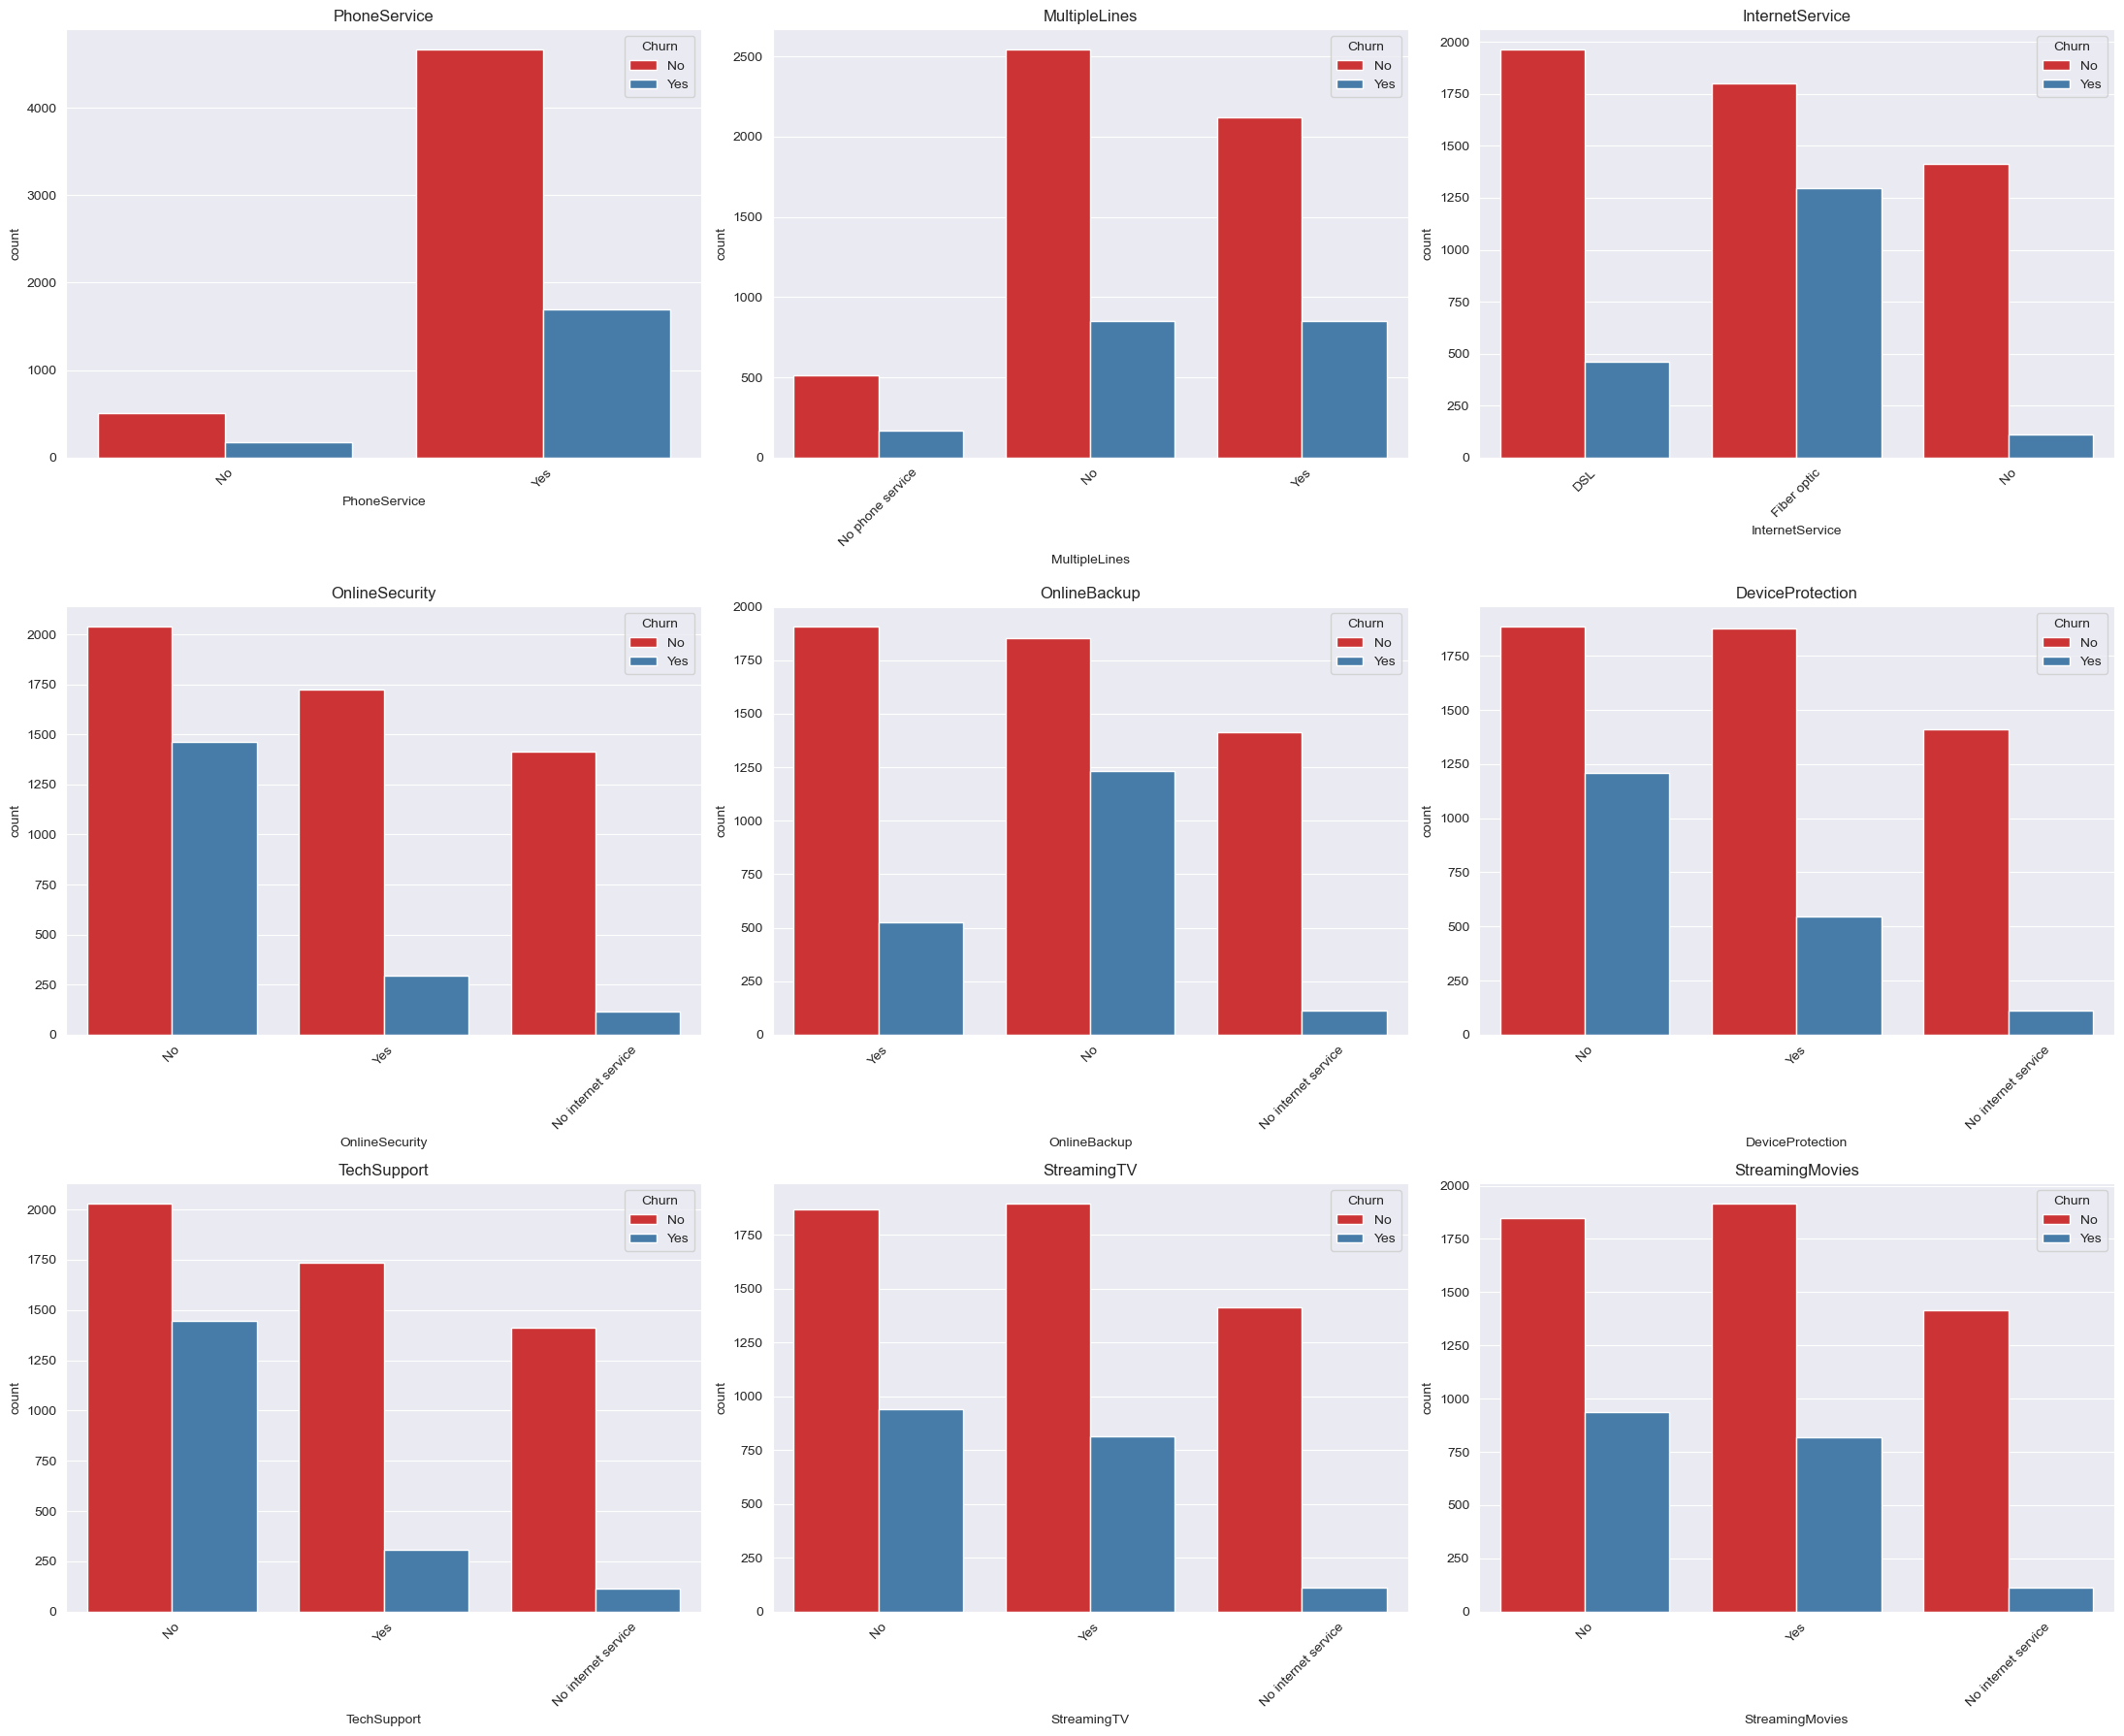

In [18]:
# List of categorical columns you want to plot
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Decide number of columns in subplot grid
n_cols = 3  

# Calculate required rows (so all plots fit properly)
n_rows = math.ceil(len(cols) / n_cols)

# Set overall figure size (height depends on number of rows)
plt.figure(figsize=(22, 6 * n_rows))

# Loop through each column and create a subplot
for i, col in enumerate(cols, 1):
    
    # Create subplot at position i
    plt.subplot(n_rows, n_cols, i)
    
    # Create countplot for the column
    sns.countplot(data=df, x=col, hue=df['Churn'])
    
    # Set title as column name
    plt.title(col)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Display all plots
plt.show()

#Customers with “No” churn dominate across all services, meaning most users are retained regardless of service type.

#Services like OnlineSecurity, TechSupport, and DeviceProtection show a noticeable pattern where users without these services churn more, indicating these features help retention.

#For InternetService (especially Fiber optic), churn is relatively higher compared to DSL, suggesting possible dissatisfaction or higher expectations.

#Streaming services (TV/Movies) don’t show a strong impact on churn, as the distribution looks fairly similar between churned and retained customers.

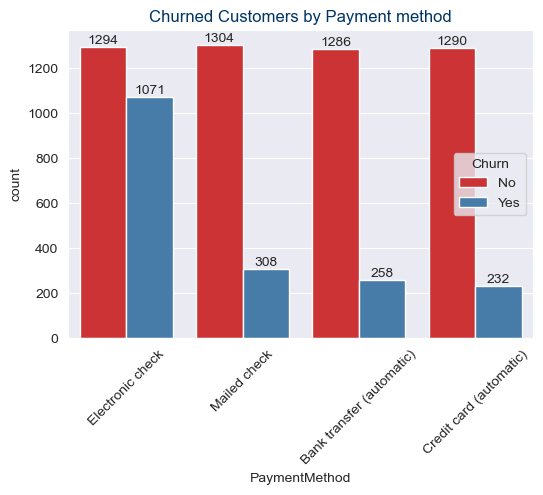

In [21]:
sns.set_style("darkgrid")   # or whitegrid, white, ticks
sns.set_palette("Set1")

plt.figure(figsize=(6,4))
ax=sns.countplot(x="PaymentMethod",data=df, hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customers by Payment method",fontsize=12, color='#003566')
plt.xticks(rotation=45)
plt.show()

#Customers is likely to churn when they are using electronic check as a payment method.